# Imports

Nesta seção são importadas as bibliotecas necessárias para:
- carregar e manipular dados (`pandas`, `numpy`);
- plotar gráficos (`matplotlib`);
- criar e avaliar modelos de regressão (`sklearn`).

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler

# Dataset

Neste bloco são carregados os conjuntos de dados de treino, validação e teste.
Os dados são lidos de arquivos CSV separados para manter o processo de avaliação correto.

In [133]:
X_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/X_training.csv')
y_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/y_training.csv').values.ravel()

In [134]:
# Carregando dados de validação/classificação
X_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/X_validation.csv')
y_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/y_validation.csv').values.ravel()

In [135]:
# Carregando dados de teste/Classificação
X_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/X_test.csv')
y_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/y_test.csv').values.ravel()

# Traning

## knn

Nesta etapa foi feito o ajuste do modelo KNN:
- treinou-se o classificador para valores de `n_neighbors` de 1 a 49;
- avaliou-se a acurácia no conjunto de validação para cada valor;
- armazenaram-se as pontuações de validação;
- foram armazenadas as pontuações de performace com dados de treinamento, validação e teste
- foi preparada a visualização da acurácia em função de `k`.

In [98]:
#modelo knn treinado com os dados de treinamento e parâmetros default
model_knn_inicial = KNeighborsClassifier()
model_knn_inicial.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [99]:
## Modelo treinado e validado com o dataset de Treinamento
values_knn = [i for i in range(1,50)]
val_scores_knn = list()

for i in values_knn:
    model_knn = KNeighborsClassifier(n_neighbors=i)
    model_knn.fit(X_train, y_train)

    yhat_val_knn = model_knn.predict(X_val)
    acc_val_knn = mt.accuracy_score(y_val, yhat_val_knn)
    val_scores_knn.append(acc_val_knn)

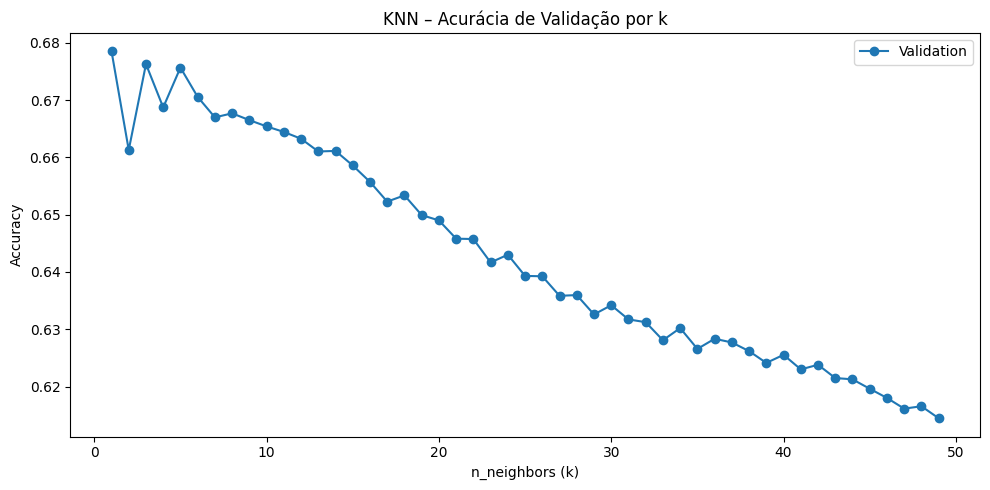

In [100]:
## plot of validation scores vs k (KNN)
plt.figure(figsize=(10, 5))
plt.plot(values_knn, val_scores_knn, '-o', label='Validation')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN – Acurácia de Validação por k')
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
## Previsão sobre os dados de validacao
yhat_val_knn = model_knn.predict( X_val )
acc_val_knn = mt.accuracy_score( y_val, yhat_val_knn )
print( "Accuracy Over Validation: {}".format( acc_val_knn ) )

Accuracy Over Validation: 0.6144663599214903


In [102]:
## Modelo treinado e validado com o dataset de Treinamento + validacao
max_index_knn = val_scores_knn.index( max( val_scores_knn ) )
model_last_knn = KNeighborsClassifier(n_neighbors=values_knn[max_index_knn])
model_last_knn.fit( pd.concat( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [103]:
print('Melhor k (n_neighbors):', values_knn[max_index_knn])

Melhor k (n_neighbors): 1


In [104]:
## Previsão sobre os dados de treinamento (modelo inicial KNN)
yhat_train_knn = model_knn_inicial.predict(X_train)
acc_train_knn      = mt.accuracy_score(y_train, yhat_train_knn)
precision_train_knn = mt.precision_score(y_train, yhat_train_knn, zero_division=0)
recall_train_knn    = mt.recall_score(y_train, yhat_train_knn, zero_division=0)
f1_score_train_knn  = mt.f1_score(y_train, yhat_train_knn, zero_division=0)

print(f'F1 Score:  {f1_score_train_knn:.4f}')
print(f'Precision: {precision_train_knn:.4f}')
print(f'Recall:    {recall_train_knn:.4f}')
print(f'Accuracy Over Training: {acc_train_knn:.4f}')

F1 Score:  0.7440
Precision: 0.7559
Recall:    0.7326
Accuracy Over Training: 0.7816


In [105]:
## Previsão sobre os dados de validação (modelo inicial KNN)
yhat_val_knn = model_knn_inicial.predict(X_val)
acc_val_knn      = mt.accuracy_score(y_val, yhat_val_knn)
precision_val_knn = mt.precision_score(y_val, yhat_val_knn, zero_division=0)
recall_val_knn    = mt.recall_score(y_val, yhat_val_knn, zero_division=0)
f1_score_val_knn  = mt.f1_score(y_val, yhat_val_knn, zero_division=0)

print(f'F1 Score:  {f1_score_val_knn:.4f}')
print(f'Precision: {precision_val_knn:.4f}')
print(f'Recall:    {recall_val_knn:.4f}')
print(f'Accuracy Over Validation: {acc_val_knn:.4f}')

F1 Score:  0.6171
Precision: 0.6318
Recall:    0.6032
Accuracy Over Validation: 0.6757


In [106]:
## Previsão sobre dados de teste (modelo final KNN – treinado em train+val)
yhat_test_knn = model_last_knn.predict(X_test)
acc_test_knn  = mt.accuracy_score(y_test, yhat_test_knn)
precision_knn = mt.precision_score(y_test, yhat_test_knn, zero_division=0)
recall_knn    = mt.recall_score(y_test, yhat_test_knn, zero_division=0)
f1_score_knn  = mt.f1_score(y_test, yhat_test_knn, zero_division=0)

print(f'F1 Score:  {f1_score_knn:.4f}')
print(f'Precision: {precision_knn:.4f}')
print(f'Recall:    {recall_knn:.4f}')
print(f'Accuracy Over Test: {acc_test_knn:.4f}')

F1 Score:  0.6598
Precision: 0.6538
Recall:    0.6659
Accuracy Over Test: 0.6986


## Decision Tree

Nesta seção foi realizado o ajuste e a avaliação de um classificador `DecisionTreeClassifier`:

- Definiu-se uma faixa de profundidades máximas (`max_depth`) de 1 a 49.
- Para cada valor de `max_depth`:
    - criou-se um modelo `DecisionTreeClassifier(max_depth=i)`;
    - treinou-se com `X_train` e `y_train`;
    - fez-se previsão sobre `X_val` (dados de validação);

- Traçou-se a curva de acurácia de validação em função de `max_depth`.

- Calculou-se a performance do último modelo treinado (`model_dt`, com `max_depth=49`) sobre:
    - dados de treinamento;
    - dados de validação.

- Selecionou-se o melhor `max_depth` usando o valor máximo de acurácia em `val_scores_dt`.

- Re-treinou-se o modelo final (`model_last_dt`) com o conjunto combinado de treinamento e validação (`X_train + X_val`, `y_train + y_val`) usando o melhor `max_depth`.

- Avaliou-se o modelo final sobre o conjunto de teste (`X_test`, `y_test`) e registrou-se:
    - acurácia;
    - precisão;
    - recall;
    - F1 score.

In [107]:
#Modelo inicial de Decision Tree treinado com os dados de treinamento e parâmetros default
model_dt_inicial = DecisionTreeClassifier()
model_dt_inicial.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [108]:
## Modelo treinado e validado com o dataset de Treinamento para encontrar o melhor valor de max_depth
values_dt = [i for i in range(1,50)]
val_scores_dt = list()

for i in values_dt:
    model_dt = DecisionTreeClassifier(max_depth=i)
    model_dt.fit(X_train, y_train)

    yhat_val_dt = model_dt.predict(X_val)
    acc_val_dt = mt.accuracy_score(y_val, yhat_val_dt)
    val_scores_dt.append(acc_val_dt)

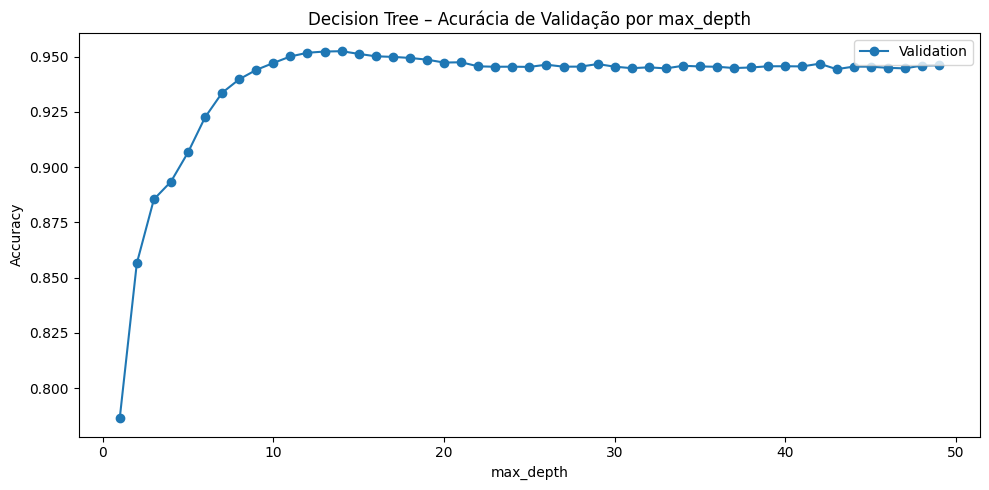

In [109]:
## plot of validation scores vs max_depth (Decision Tree)
plt.figure(figsize=(10, 5))
plt.plot(values_dt, val_scores_dt, '-o', label='Validation')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree – Acurácia de Validação por max_depth')
plt.legend()
plt.tight_layout()
plt.show()

In [110]:
## Previsão sobre os dados de treinamento (modelo inicial DT)
yhat_train_dt = model_dt_inicial.predict(X_train)
acc_train_dt      = mt.accuracy_score(y_train, yhat_train_dt)
precision_train_dt = mt.precision_score(y_train, yhat_train_dt, zero_division=0)
recall_train_dt    = mt.recall_score(y_train, yhat_train_dt, zero_division=0)
f1_score_train_dt  = mt.f1_score(y_train, yhat_train_dt, zero_division=0)

print(f'F1 Score:  {f1_score_train_dt:.4f}')
print(f'Precision: {precision_train_dt:.4f}')
print(f'Recall:    {recall_train_dt:.4f}')
print(f'Accuracy Over Training: {acc_train_dt:.4f}')

F1 Score:  1.0000
Precision: 1.0000
Recall:    1.0000
Accuracy Over Training: 1.0000


In [111]:
## Previsão sobre os dados de validação (modelo inicial DT)
yhat_val_dt = model_dt_inicial.predict(X_val)
acc_val_dt      = mt.accuracy_score(y_val, yhat_val_dt)
precision_val_dt = mt.precision_score(y_val, yhat_val_dt, zero_division=0)
recall_val_dt    = mt.recall_score(y_val, yhat_val_dt, zero_division=0)
f1_score_val_dt  = mt.f1_score(y_val, yhat_val_dt, zero_division=0)

print(f'F1 Score:  {f1_score_val_dt:.4f}')
print(f'Precision: {precision_val_dt:.4f}')
print(f'Recall:    {recall_val_dt:.4f}')
print(f'Accuracy Over Validation: {acc_val_dt:.4f}')

F1 Score:  0.9370
Precision: 0.9363
Recall:    0.9378
Accuracy Over Validation: 0.9454


In [112]:
## Modelo treinado e validado com o dataset de Treinamento
max_index_dt = val_scores_dt.index( max( val_scores_dt ) ) # Encontrar o índice do valor máximo de acurácia na lista de acurácias de validação
model_last_dt = DecisionTreeClassifier(max_depth=values_dt[max_index_dt])
model_last_dt.fit( pd.concat( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [113]:
## Previsão sobre dados de teste (modelo final DT)
yhat_test_dt = model_last_dt.predict(X_test)
acc_test_dt  = mt.accuracy_score(y_test, yhat_test_dt)
precision_dt = mt.precision_score(y_test, yhat_test_dt, zero_division=0)
recall_dt    = mt.recall_score(y_test, yhat_test_dt, zero_division=0)
f1_score_dt  = mt.f1_score(y_test, yhat_test_dt, zero_division=0)

print(f'F1 Score:  {f1_score_dt:.4f}')
print(f'Precision: {precision_dt:.4f}')
print(f'Recall:    {recall_dt:.4f}')
print(f'Accuracy Over Test: {acc_test_dt:.4f}')

F1 Score:  0.9499
Precision: 0.9562
Recall:    0.9436
Accuracy Over Test: 0.9563


## Random Forest

Nesta seção foi ajustado e avaliado um classificador `RandomForestClassifier`.

- Foi testado um conjunto de valores para `n_estimators` e `max_depth` usando o conjunto de validação.
- Para cada combinação de parâmetros:
    - o modelo foi treinado em `X_train` e `y_train`;
    - foi feita a previsão em `X_val`;
    - calculou-se a acurácia de validação.
- A melhor combinação de parâmetros foi identificada com base na maior acurácia em validação.
- Em seguida, o modelo final foi re-treinado usando o conjunto combinado de treinamento e validação (`X_train + X_val`, `y_train + y_val`).
- Por fim, o modelo inicial foi avaliado com dados de treinamento, validação e o modelos final ajustado foi avaliado com os dados de teste, registrando acurácia, precisão, recall e F1 score.

In [114]:
# Random Forest treinado com parâmetros default e random_state fixo
model_rf_inicial = RandomForestClassifier(random_state=42)
model_rf_inicial.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [115]:
# Modelo treinado e validado com o dataset de Treinamento para encontrar o melhor valor de n_estimators
values_rf = [40, 41, 42, 46]
values_max_depth = [29, 30, 31, 33]

val_scores_rf = []
best_rf = {'n_estimators': None, 'max_depth': None, 'accuracy': 0.0}

for n in values_rf:
    best_acc_for_n = 0.0
    for max_depth in values_max_depth:
        model_rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, random_state=42)
        model_rf.fit(X_train, y_train)

        yhat_val_rf = model_rf.predict(X_val)
        acc_val_rf = mt.accuracy_score(y_val, yhat_val_rf)

        if acc_val_rf > best_acc_for_n:
            best_acc_for_n = acc_val_rf

        if acc_val_rf > best_rf['accuracy']:
            best_rf.update({
                'n_estimators': n,
                'max_depth': max_depth,
                'accuracy': acc_val_rf
            })

    val_scores_rf.append(best_acc_for_n)

print('Melhor combinação:', best_rf)

Melhor combinação: {'n_estimators': 42, 'max_depth': 29, 'accuracy': 0.964606325814859}


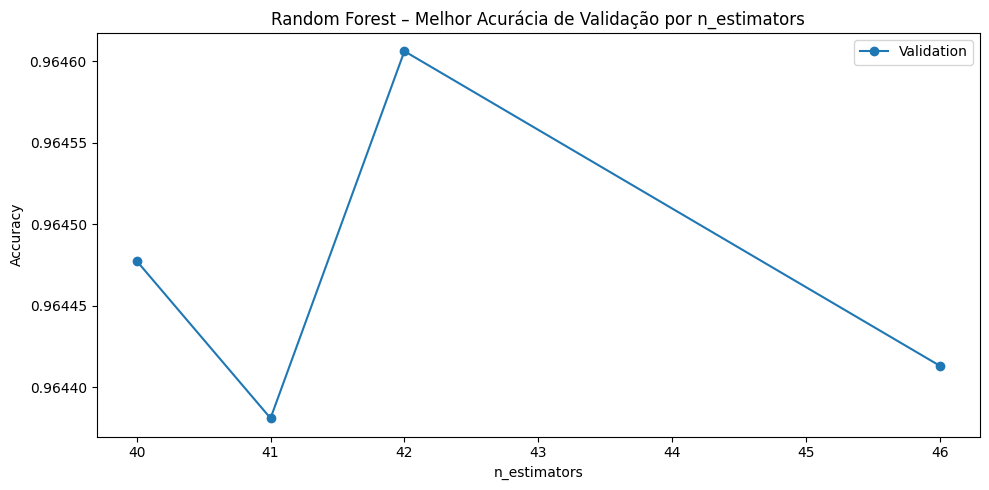

In [116]:
## plot de acurácia de validação vs n_estimators (Random Forest)
plt.figure(figsize=(10, 5))
plt.plot(values_rf, val_scores_rf, '-o', label='Validation')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest – Melhor Acurácia de Validação por n_estimators')
plt.legend()
plt.tight_layout()
plt.show()

In [117]:
## Previsão sobre os dados de validacao
yhat_val_rf = model_rf.predict( X_val )
acc_val_rf = mt.accuracy_score( y_val, yhat_val_rf )
print( "Accuracy Over Validation: {}".format( acc_val_rf ) )

Accuracy Over Validation: 0.9644132694102127


In [118]:
## Modelo final RF treinado em train+val com os melhores hiperparâmetros
max_index_rf = val_scores_rf.index(max(val_scores_rf))
model_last_rf = RandomForestClassifier(
    n_estimators=best_rf['n_estimators'],
    max_depth=best_rf['max_depth'],
    random_state=42
)
model_last_rf.fit(pd.concat((X_train, X_val)), np.concatenate((y_train, y_val)))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",29
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [119]:
## Previsão sobre os dados de treinamento (modelo inicial RF)
yhat_train_rf = model_rf_inicial.predict(X_train)
acc_train_rf      = mt.accuracy_score(y_train, yhat_train_rf)
precision_train_rf = mt.precision_score(y_train, yhat_train_rf, zero_division=0)
recall_train_rf    = mt.recall_score(y_train, yhat_train_rf, zero_division=0)
f1_score_train_rf  = mt.f1_score(y_train, yhat_train_rf, zero_division=0)

print(f'F1 Score:  {f1_score_train_rf:.4f}')
print(f'Precision: {precision_train_rf:.4f}')
print(f'Recall:    {recall_train_rf:.4f}')
print(f'Accuracy Over Training: {acc_train_rf:.4f}')

F1 Score:  1.0000
Precision: 1.0000
Recall:    1.0000
Accuracy Over Training: 1.0000


In [120]:
## Previsão sobre os dados de validação (modelo inicial RF)
yhat_val_rf = model_rf_inicial.predict(X_val)
acc_val_rf      = mt.accuracy_score(y_val, yhat_val_rf)
precision_val_rf = mt.precision_score(y_val, yhat_val_rf, zero_division=0)
recall_val_rf    = mt.recall_score(y_val, yhat_val_rf, zero_division=0)
f1_score_val_rf  = mt.f1_score(y_val, yhat_val_rf, zero_division=0)

print(f'F1 Score:  {f1_score_val_rf:.4f}')
print(f'Precision: {precision_val_rf:.4f}')
print(f'Recall:    {recall_val_rf:.4f}')
print(f'Accuracy Over Validation: {acc_val_rf:.4f}')

F1 Score:  0.9593
Precision: 0.9742
Recall:    0.9448
Accuracy Over Validation: 0.9652


In [121]:
## Previsão sobre dados de teste (modelo final RF)
yhat_test_rf = model_last_rf.predict(X_test)
acc_test_rf  = mt.accuracy_score(y_test, yhat_test_rf)
precision_rf = mt.precision_score(y_test, yhat_test_rf, zero_division=0)
recall_rf    = mt.recall_score(y_test, yhat_test_rf, zero_division=0)
f1_score_rf  = mt.f1_score(y_test, yhat_test_rf, zero_division=0)

print(f'F1 Score:  {f1_score_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall:    {recall_rf:.4f}')
print(f'Accuracy Over Test: {acc_test_rf:.4f}')

F1 Score:  0.9592
Precision: 0.9743
Recall:    0.9445
Accuracy Over Test: 0.9647


## Logistic Regressor

Nesta seção foi ajustado e avaliado um classificador `LogisticRegression`:

- treinou-se o modelo usando os dados de treinamento;
- avaliou-se a acurácia no conjunto de validação;
- gerou-se um gráfico com as pontuações de validação;
- re-treinou-se o modelo final com os dados combinados de treinamento e validação;
- avaliou-se o desempenho final no conjunto de teste usando acurácia, precisão, recall e F1-score.

In [122]:
# Normalizar os dados — fazer isso UMA vez antes de treinar, necessário para modelos como Logistic Regression e KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit apenas no treino, porque queremos que a normalização seja baseada apenas nos dados de treinamento, para evitar vazamento de informação dos dados de validação e teste.
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [123]:
# Logistic Regression treinado com parâmetros default (max_iter aumentado para convergência)
model_lr_inicial = LogisticRegression(max_iter=1000)
model_lr_inicial.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [124]:
## Busca pelo melhor C para Logistic Regression
values_lr = [0.001, 0.01, 0.1, 1, 10, 50]
val_scores_lr = []

for c in values_lr:
    model_lr = LogisticRegression(C=c, solver='lbfgs', max_iter=1000)
    model_lr.fit(X_train_scaled, y_train)

    yhat_val_lr = model_lr.predict(X_val_scaled)
    acc_val_lr = mt.accuracy_score(y_val, yhat_val_lr)
    val_scores_lr.append(acc_val_lr)

In [125]:
## Previsão do modelo inicial sobre os dados de treinamento (LR)
yhat_train_lr = model_lr_inicial.predict(X_train_scaled)
acc_train_lr      = mt.accuracy_score(y_train, yhat_train_lr)
precision_train_lr = mt.precision_score(y_train, yhat_train_lr, zero_division=0)
recall_train_lr    = mt.recall_score(y_train, yhat_train_lr, zero_division=0)
f1_score_train_lr  = mt.f1_score(y_train, yhat_train_lr, zero_division=0)

print(f'F1 Score:  {f1_score_train_lr:.4f}')
print(f'Precision: {precision_train_lr:.4f}')
print(f'Recall:    {recall_train_lr:.4f}')
print(f'Accuracy Over Training: {acc_train_lr:.4f}')

F1 Score:  0.8542
Precision: 0.8718
Recall:    0.8374
Accuracy Over Training: 0.8761


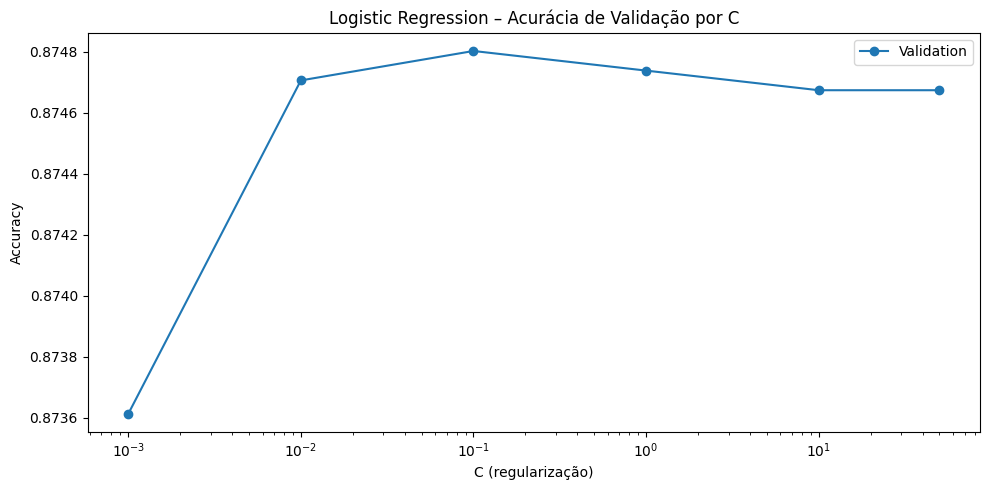

In [126]:
## plot de acurácia de validação vs C (Logistic Regression)
plt.figure(figsize=(10, 5))
plt.plot(values_lr, val_scores_lr, '-o', label='Validation')
plt.xscale('log')
plt.xlabel('C (regularização)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression – Acurácia de Validação por C')
plt.legend()
plt.tight_layout()
plt.show()

In [127]:
## Previsão do modelo inicial sobre os dados de validação (LR)
yhat_val_lr = model_lr_inicial.predict(X_val_scaled)
acc_val_lr      = mt.accuracy_score(y_val, yhat_val_lr)
precision_val_lr = mt.precision_score(y_val, yhat_val_lr, zero_division=0)
recall_val_lr    = mt.recall_score(y_val, yhat_val_lr, zero_division=0)
f1_score_val_lr  = mt.f1_score(y_val, yhat_val_lr, zero_division=0)

print(f'F1 Score:  {f1_score_val_lr:.4f}')
print(f'Precision: {precision_val_lr:.4f}')
print(f'Recall:    {recall_val_lr:.4f}')
print(f'Accuracy Over Validation: {acc_val_lr:.4f}')

F1 Score:  0.8527
Precision: 0.8697
Recall:    0.8363
Accuracy Over Validation: 0.8747


In [128]:
## Modelo final LR treinado em train+val com o melhor C
max_index_lr = val_scores_lr.index(max(val_scores_lr))
best_C = values_lr[max_index_lr]
print(f'Melhor C encontrado: {best_C}')

model_last_lr = LogisticRegression(C=best_C, solver='lbfgs', max_iter=1000)
model_last_lr.fit(np.vstack([X_train_scaled, X_val_scaled]), np.concatenate((y_train, y_val)))

Melhor C encontrado: 0.1


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [129]:
## Previsão sobre dados de teste (modelo final LR)
yhat_test_lr = model_last_lr.predict(X_test_scaled)
acc_test_lr  = mt.accuracy_score(y_test, yhat_test_lr)
precision_lr = mt.precision_score(y_test, yhat_test_lr, zero_division=0)
recall_lr    = mt.recall_score(y_test, yhat_test_lr, zero_division=0)
f1_score_lr  = mt.f1_score(y_test, yhat_test_lr, zero_division=0)

print(f'F1 Score:  {f1_score_lr:.4f}')
print(f'Precision: {precision_lr:.4f}')
print(f'Recall:    {recall_lr:.4f}')
print(f'Accuracy Over Test: {acc_test_lr:.4f}')

F1 Score:  0.8516
Precision: 0.8687
Recall:    0.8351
Accuracy Over Test: 0.8722


# Resultados

## Resultados de treinamento

In [130]:
# Resultados de treinamento
resultados_train = pd.DataFrame({
    'Algoritmo':   ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Acurácia':    [f'{acc_train_knn:.3f}', f'{acc_train_dt:.3f}', f'{acc_train_rf:.3f}', f'{acc_train_lr:.3f}'],
    'Precision':   [f'{precision_train_knn:.3f}', f'{precision_train_dt:.3f}', f'{precision_train_rf:.3f}', f'{precision_train_lr:.3f}'],
    'Recall':      [f'{recall_train_knn:.3f}', f'{recall_train_dt:.3f}', f'{recall_train_rf:.3f}', f'{recall_train_lr:.3f}'],
    'F1_score':    [f'{f1_score_train_knn:.3f}', f'{f1_score_train_dt:.3f}', f'{f1_score_train_rf:.3f}', f'{f1_score_train_lr:.3f}']
})
print(resultados_train.to_string(index=False))

          Algoritmo Acurácia Precision Recall F1_score
                KNN    0.782     0.756  0.733    0.744
      Decision Tree    1.000     1.000  1.000    1.000
      Random Forest    1.000     1.000  1.000    1.000
Logistic Regression    0.876     0.872  0.837    0.854


## Resultados de validação

In [131]:
# Resultados de validação
resultados_val = pd.DataFrame({
    'Algoritmo':   ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Acurácia':    [f'{acc_val_knn:.3f}', f'{acc_val_dt:.3f}', f'{acc_val_rf:.3f}', f'{acc_val_lr:.3f}'],
    'Precision':   [f'{precision_val_knn:.3f}', f'{precision_val_dt:.3f}', f'{precision_val_rf:.3f}', f'{precision_val_lr:.3f}'],
    'Recall':      [f'{recall_val_knn:.3f}', f'{recall_val_dt:.3f}', f'{recall_val_rf:.3f}', f'{recall_val_lr:.3f}'],
    'F1_score':    [f'{f1_score_val_knn:.3f}', f'{f1_score_val_dt:.3f}', f'{f1_score_val_rf:.3f}', f'{f1_score_val_lr:.3f}']
})
print(resultados_val.to_string(index=False))

          Algoritmo Acurácia Precision Recall F1_score
                KNN    0.676     0.632  0.603    0.617
      Decision Tree    0.945     0.936  0.938    0.937
      Random Forest    0.965     0.974  0.945    0.959
Logistic Regression    0.875     0.870  0.836    0.853


## Resultados validados e testados

In [132]:
# Resultados de teste
resultados_test = pd.DataFrame({
    'Algoritmo':   ['KNN', 'Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Acurácia':    [f'{acc_test_knn:.3f}', f'{acc_test_dt:.3f}', f'{acc_test_rf:.3f}', f'{acc_test_lr:.3f}'],
    'Precision':   [f'{precision_knn:.3f}', f'{precision_dt:.3f}', f'{precision_rf:.3f}', f'{precision_lr:.3f}'],
    'Recall':      [f'{recall_knn:.3f}', f'{recall_dt:.3f}', f'{recall_rf:.3f}', f'{recall_lr:.3f}'],
    'F1_score':    [f'{f1_score_knn:.3f}', f'{f1_score_dt:.3f}', f'{f1_score_rf:.3f}', f'{f1_score_lr:.3f}']
})
resultados_test

,Algoritmo,Acurácia,Precision,Recall,F1_score
0,KNN,0.699,0.654,0.666,0.660
1,Decision Tree,0.956,0.956,0.944,0.950
2,Random Forest,0.965,0.974,0.944,0.959
3,Logistic Regression,0.872,0.869,0.835,0.852
